In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_dosya_yolu = "/content/drive/MyDrive/Colab Notebooks/archive2.zip"
!unzip -o "$zip_dosya_yolu" -d "/content/drive/MyDrive/Colab Notebooks/"

Archive:  /content/drive/MyDrive/Colab Notebooks/archive2.zip


In [ ]:
import os

klasor_yolu = "/content/drive/MyDrive/Colab Notebooks/"
print(os.listdir(klasor_yolu))
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/COVID-19_Radiography_Dataset"))

for root, dirs, files in os.walk(klasor_yolu):
    png_dosyalar = [f for f in files if f.endswith('.png')]
    if png_dosyalar:
        print(f"{root} içinde {len(png_dosyalar)} adet PNG dosyası bulundu.")

['archive.zip', 'archive2.zip', 'COVID-19_Radiography_Dataset', 'splitted_dataset', 'quiz.ipynb', 'Untitled0.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'densenet.ipynb', 'Untitled3.ipynb', 'car_detection.zip', 'Untitled4.ipynb']
['COVID', 'Normal', 'Viral Pneumonia']


KeyboardInterrupt: 

In [ ]:
import os
hedef_konum = "/content/drive/MyDrive/Colab Notebooks/splitted_dataset"

for set_tipi in ["train", "val", "test"]:
    for sinif in ["COVID", "Normal", "Viral Pneumonia"]:
        os.makedirs(os.path.join(hedef_konum, set_tipi, sinif), exist_ok=True)

print("Klasör yapısı oluşturuldu!")

Klasör yapısı oluşturuldu!


In [ ]:
import shutil
import random
import os

orijinal_dataset = "/content/drive/MyDrive/Colab Notebooks/COVID-19_Radiography_Dataset"
hedef_dataset = "/content/drive/MyDrive/Colab Notebooks/splitted_dataset"

train_oran, val_oran, test_oran = 0.7, 0.15, 0.15

siniflar = {
    "COVID": "COVID/images",
    "Normal": "Normal/images",
    "Viral Pneumonia": "Viral Pneumonia/images"
}

def veriyi_bol(sinif_adi, kaynak_klasor):
    dosyalar = os.listdir(os.path.join(orijinal_dataset, kaynak_klasor))
    dosyalar = [f for f in dosyalar if f.endswith('.png')]
    random.shuffle(dosyalar)

    train_sayisi = int(len(dosyalar) * train_oran)
    val_sayisi = int(len(dosyalar) * val_oran)

    train_dosyalar = dosyalar[:train_sayisi]
    val_dosyalar = dosyalar[train_sayisi:train_sayisi + val_sayisi]
    test_dosyalar = dosyalar[train_sayisi + val_sayisi:]


    for dosya in train_dosyalar:
        shutil.copy(os.path.join(orijinal_dataset, kaynak_klasor, dosya), os.path.join(hedef_dataset, "train", sinif_adi, dosya))

    for dosya in val_dosyalar:
        shutil.copy(os.path.join(orijinal_dataset, kaynak_klasor, dosya), os.path.join(hedef_dataset, "val", sinif_adi, dosya))

    for dosya in test_dosyalar:
        shutil.copy(os.path.join(orijinal_dataset, kaynak_klasor, dosya), os.path.join(hedef_dataset, "test", sinif_adi, dosya))


for sinif_adi, kaynak_klasor in siniflar.items():
    veriyi_bol(sinif_adi, kaynak_klasor)

print("Veri başarıyla bölündü!")


Veri başarıyla bölündü!


In [ ]:
for set_tipi in ["train", "val", "test"]:
    for sinif in ["COVID", "Normal", "Viral Pneumonia"]:
        klasor = os.path.join(hedef_dataset, set_tipi, sinif)
        print(f"{set_tipi} - {sinif}: {len(os.listdir(klasor))} resim")

train - COVID: 3613 resim
train - Normal: 10185 resim
train - Viral Pneumonia: 1339 resim
val - COVID: 2454 resim
val - Normal: 6392 resim
val - Viral Pneumonia: 755 resim
test - COVID: 2456 resim
test - Normal: 5767 resim
test - Viral Pneumonia: 743 resim


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout
from tensorflow.keras.preprocessing.image  import ImageDataGenerator
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report,confusion_matrix

import tensorflow as tf

import cv2
import os

import numpy as np

In [ ]:
base_dir = "/content/drive/MyDrive/Colab Notebooks/splitted_dataset"


train_datagen = ImageDataGenerator(rescale=1.0/255, rotation_range=40, width_shift_range=0.3, height_shift_range=0.3,
                                   shear_range=0.3, zoom_range=0.4, brightness_range=(0.7, 1.3), horizontal_flip=True, fill_mode='nearest')

val_datagen = ImageDataGenerator(rescale=1.0/255)

batch_size = 16
img_size = (224, 224)

train_generator = train_datagen.flow_from_directory(os.path.join(base_dir, 'train'), target_size=img_size,
                                                    batch_size=batch_size, class_mode='categorical')

val_generator = val_datagen.flow_from_directory(os.path.join(base_dir, 'val'), target_size=img_size,
                                                batch_size=batch_size, class_mode='categorical')

test_generator = val_datagen.flow_from_directory(os.path.join(base_dir, 'test'), target_size=img_size,
                                                 batch_size=batch_size, class_mode='categorical', shuffle=False)

print("Sınıflar:", train_generator.class_indices)


Found 15137 images belonging to 3 classes.
Found 9601 images belonging to 3 classes.
Found 8966 images belonging to 3 classes.
Sınıflar: {'COVID': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [ ]:
def resnet_block(x, filters, kernel_size=3, stride=1, weight_decay=1e-3):
    shortcut = x

    x = Conv2D(filters, kernel_size, strides=stride, padding="same",
               kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, strides=1, padding="same",
               kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding="same",
                          kernel_regularizer=regularizers.l2(weight_decay))(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


In [ ]:
from tensorflow.keras.layers import Input, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Conv2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers


def build_resnet101(input_shape=(224, 224, 3), num_classes=3, dropout_rate=0.5):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, 7, strides=2, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)


    x = resnet_block(x, 64)
    x = resnet_block(x, 64)
    x = resnet_block(x, 64)

    x = resnet_block(x, 128, stride=2)
    x = resnet_block(x, 128)
    x = resnet_block(x, 128)
    x = resnet_block(x, 128)

    x = resnet_block(x, 256, stride=2)
    x = resnet_block(x, 256)
    x = resnet_block(x, 256)
    x = resnet_block(x, 256)
    x = resnet_block(x, 256)
    x = resnet_block(x, 256)

    x = resnet_block(x, 512, stride=2)
    x = resnet_block(x, 512)
    x = resnet_block(x, 512)


    x = GlobalAveragePooling2D()(x)


    x = Dropout(dropout_rate)(x)


    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model




In [ ]:
model = build_resnet101(dropout_rate=0.5)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 21,311,747 (81.30 MB)

 Trainable params: 21,294,723 (81.23 MB)

 Non-trainable params: 17,024 (66.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

In [ ]:
epochs = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=[early_stopping, checkpoint]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6296 - loss: 8.6280
Epoch 1: val_loss improved from inf to 7.89187, saving model to best_model.h5


947/947 ━━━━━━━━━━━━━━━━━━━━ 9551s 10s/step - accuracy: 0.6297 - loss: 8.6274 - val_accuracy: 0.5647 - val_loss: 7.8919
Epoch 2/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6944 - loss: 6.5281
Epoch 2: val_loss improved from 7.89187 to 6.16438, saving model to best_model.h5


947/947 ━━━━━━━━━━━━━━━━━━━━ 2040s 2s/step - accuracy: 0.6944 - loss: 6.5276 - val_accuracy: 0.6665 - val_loss: 6.1644
Epoch 3/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7150 - loss: 4.6379
Epoch 3: val_loss improved from 6.16438 to 3.86359, saving model to best_model.h5


947/947 ━━━━━━━━━━━━━━━━━━━━ 2042s 2s/step - accuracy: 0.7150 - loss: 4.6375 - val_accuracy: 0.7274 - val_loss: 3.8636
Epoch 4/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7433 - loss: 3.2302
Epoch 4: val_loss improved from 3.86359 to 3.08785, saving model to best_model.h5


947/947 ━━━━━━━━━━━━━━━━━━━━ 2063s 2s/step - accuracy: 0.7433 - loss: 3.2300 - val_accuracy: 0.5839 - val_loss: 3.0879
Epoch 5/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7641 - loss: 2.3940
Epoch 5: val_loss did not improve from 3.08785
947/947 ━━━━━━━━━━━━━━━━━━━━ 2011s 2s/step - accuracy: 0.7641 - loss: 2.3938 - val_accuracy: 0.6948 - val_loss: 6.1646
Epoch 6/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7894 - loss: 1.8425
Epoch 6: val_loss improved from 3.08785 to 1.78709, saving model to best_model.h5


947/947 ━━━━━━━━━━━━━━━━━━━━ 2060s 2s/step - accuracy: 0.7894 - loss: 1.8424 - val_accuracy: 0.7432 - val_loss: 1.7871
Epoch 7/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7960 - loss: 1.5466
Epoch 7: val_loss improved from 1.78709 to 1.70627, saving model to best_model.h5


947/947 ━━━━━━━━━━━━━━━━━━━━ 2112s 2s/step - accuracy: 0.7960 - loss: 1.5466 - val_accuracy: 0.6675 - val_loss: 1.7063
Epoch 8/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7975 - loss: 1.3563
Epoch 8: val_loss did not improve from 1.70627
947/947 ━━━━━━━━━━━━━━━━━━━━ 2074s 2s/step - accuracy: 0.7975 - loss: 1.3563 - val_accuracy: 0.5634 - val_loss: 2.0133
Epoch 9/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8220 - loss: 1.1758
Epoch 9: val_loss did not improve from 1.70627
947/947 ━━━━━━━━━━━━━━━━━━━━ 2043s 2s/step - accuracy: 0.8220 - loss: 1.1758 - val_accuracy: 0.3528 - val_loss: 2.4841
Epoch 10/10
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8198 - loss: 1.0794
Epoch 10: val_loss improved from 1.70627 to 1.29028, saving model to best_model.h5


947/947 ━━━━━━━━━━━━━━━━━━━━ 1996s 2s/step - accuracy: 0.8198 - loss: 1.0794 - val_accuracy: 0.6908 - val_loss: 1.2903
Restoring model weights from the end of the best epoch: 10.


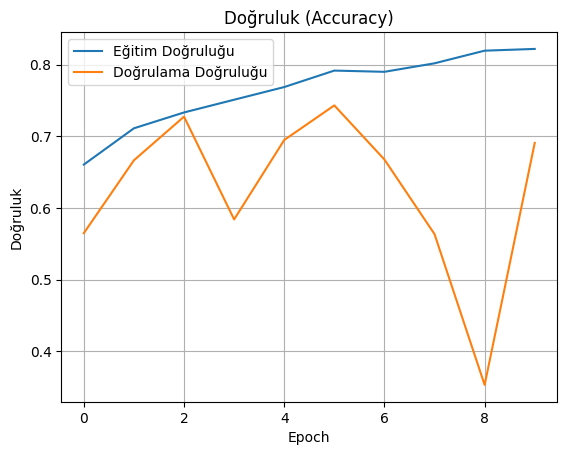

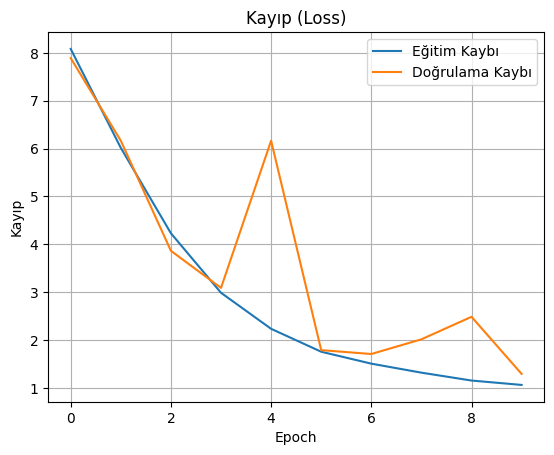

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Doğruluk (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Kayıp (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid(True)
plt.show()


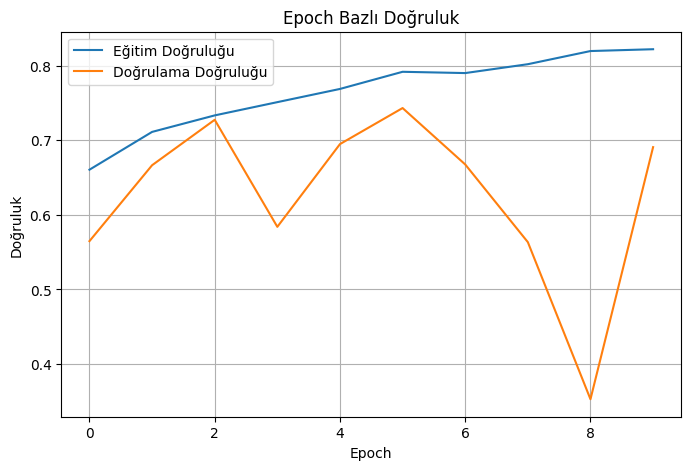

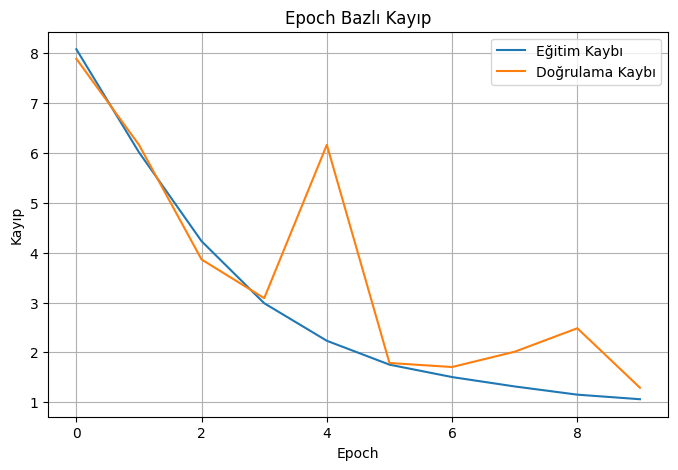

In [ ]:
import matplotlib.pyplot as plt

# Doğruluk (Accuracy) grafiği
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Epoch Bazlı Doğruluk')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.grid(True)
plt.show()

# Kayıp (Loss) grafiği
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Epoch Bazlı Kayıp')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid(True)
plt.show()
